In [7]:
# Check if autoreload is loaded and load/reload accordingly
try:
    %reload_ext autoreload
except Exception:
    %load_ext autoreload
%autoreload 2

# from tqdm.notebook import tqdm

# Basic useful imports
import yaml
from pathlib import Path
import h5py
from cycler import cycler

# Data manipulation
import numpy as np
from scipy.integrate import quad
import scipy.stats as stats
from scipy.optimize import root_scalar

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

# Clustering stuff
from itertools import cycle
# plt.cm.tab20.colors

# From alens_analysis.py
import alens_analysis.chromatin.chrom_analysis as ca
import alens_analysis.chromatin.chrom_graph_funcs as cgf
from alens_analysis import cluster_analysis as cla

# Locations
ws_path = Path("/home/alamson/DATA/Chromatin/")
mnt_path = Path.home() / "projects/DATA/Chromatin/"
ceph_path = Path.home() / "ceph/DATA/Chromatin/"

image_path = Path("/mnt/home/alamson/papers/dyn_cond_paper/images/")


In [8]:
# Consistent settings
ss_ind = 1
end_ind = None
start_bead = 0
end_bead = None
part_min = 40

# Diffusion time
visc = 1.0 # pN*s/um^2
b_diam = 0.01 # um
kbT = .00411 # pN*um
L_tot = 1600 # beads
L_tot_um = L_tot * b_diam
bead_diff = kbT / (3 * np.pi * visc * b_diam) # um^2/s
diff_time =  b_diam**2 / (6*bead_diff) # s
print(f"Diffusion time: {diff_time:.5f} s")

Diffusion time: 0.00038 s


### Style settings

In [9]:
graph_sty = {
    "axes.titlesize": 20,
    "axes.labelsize": 24,
    "lines.linewidth": 2,
    "lines.markersize": 2,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "font.size": 20,
    "text.usetex": False,
    "mathtext.fontset": "cm",
}
plt.style.use(graph_sty)

colors = cycle(mcolors.XKCD_COLORS.keys())
plt.rcParams["image.cmap"] = "YlOrRd"

def reset_scale(fig, new_width):
    w_old, h_old = fig.get_size_inches()

    fig.set_size_inches(new_width, new_width * h_old / w_old)
    scale = new_width / w_old
    mpl.rcParams["axes.titlesize"] *= scale
    mpl.rcParams["axes.labelsize"] *= scale
    mpl.rcParams["lines.linewidth"] *= scale
    mpl.rcParams["lines.markersize"] *= scale
    mpl.rcParams["xtick.labelsize"] *= scale
    mpl.rcParams["ytick.labelsize"] *= scale
    mpl.rcParams["font.size"] *= scale

# Supplement figures

In [10]:
data_path = (
    ceph_path
    / "DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100"
)
vmax = 40  # Max colorbar value in kymographs

h5_list = list(data_path.glob("simulations/*/s1/analysis/raw*.h5"))
print(len(h5_list))
data_dict = {}
for h5d in h5_list:
    with h5py.File(h5d, "r") as h5_data:
        run_params = yaml.safe_load(h5_data.attrs["RunConfig"])
        prot_params = yaml.safe_load(h5_data.attrs["ProteinConfig"])
        contact_file = h5d.parent / "contact_analysis.h5"

        pin_dist = run_params["pinDist"]
        Ke = prot_params["proteins"][0]["Ke"][1]

        if pin_dist not in data_dict:
            data_dict[pin_dist] = {}
        data_dict[pin_dist][Ke] = contact_file

pin_dist_list = sorted(data_dict.keys())
print("pin_dist_list: ", pin_dist_list)
ke_list = sorted(data_dict[pin_dist].keys())
print("ke_list: ", ke_list)

25
pin_dist_list:  [3.0, 5.0, 7.0, 9.0, 11.0]
ke_list:  [1.0, 3.0, 10.0, 30.0, 100.0]


In [ ]:
fig, axarr = plt.subplots(
    len(pin_dist_list), len(ke_list), figsize=(16, 12), sharex=True, sharey=True
)
for i, pin_dist in enumerate(pin_dist_list):
    for j, ke in enumerate(ke_list):
        try:
            with h5py.File(data_dict[pin_dist][ke], "r") as h5_data:
                time_arr = h5_data["time"][...]/diff_time
                contact_kymo = h5_data["contact_kymo"][...]

            cgf.plot_contact_kymo(
                fig, axarr[i, j], time_arr, contact_kymo, vmax=vmax, label_flag=False
            )
        except Exception:
            print(f"Error occured at pin_dist: {pin_dist}, ke: {ke}")
            # raise
            pass


for axarr_row in axarr:
    _ = axarr_row[0].set_ylabel("Bead index")

for bottom_row in axarr[-1]:
    _ = bottom_row.set_xlabel(r"$t/\tau_b$")

fig.tight_layout()


# fig.savefig("SFig_contact_kymos/fig_supp_contact_kymos.pdf", dpi=600, bbox_inches="tight")
# fig.savefig("SFig_contact_kymos/fig_supp_contact_kymos.eps", dpi=600, bbox_inches="tight")
fig.savefig("SFig_contact_kymos/fig_supp_contact_kymos.png", dpi=600, bbox_inches="tight")
fig.savefig(image_path / "fig_supp_contact_kymos.png", dpi=600, bbox_inches="tight")
# fig.savefig(image_path / "fig_supp_contact_kymos.eps", dpi=600, bbox_inches="tight")
# fig.savefig(image_path / "fig_supp_contact_kymos.pdf", dpi=600, bbox_inches="tight")
# Takes about 4 minutes to graph + long time to create the eps and pdf files.


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x155551672590>>
Traceback (most recent call last):
  File "/mnt/home/alamson/miniforge3/envs/alens/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


# Collect data

In [ ]:
slice_path = (
    ceph_path
    / "DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations"
)

pin_ke_data_dict = {}


def parse_params(param_dir):
    for data_path in param_dir.glob("s*/analysis/raw_data.h5"):
        try:
            with h5py.File(data_path, "r") as h5_data:
                run_params = yaml.safe_load(h5_data.attrs["RunConfig"])
                prot_params = yaml.safe_load(h5_data.attrs["ProteinConfig"])
            return run_params["pinDist"], prot_params["proteins"][0]["Ke"][1]
        except Exception:
            print("Error occured while parsing ", data_path)
            continue


for param_dir in slice_path.glob("*"):
    print(param_dir)
    pin_dist, Ke = parse_params(param_dir)
    if pin_dist not in pin_ke_data_dict:
        pin_ke_data_dict[pin_dist] = {}

    sd_h5_file_lst = [h5p for h5p in param_dir.glob("s*/analysis/raw_data.h5")]

    num_runs = len(sd_h5_file_lst)
    try:
        min_run_length = min(
            [len(h5py.File(h5p, "r")["time"]) for h5p in sd_h5_file_lst]
        )
    except Exception:
        print(
            "Error occured while trying to find min_run_length in param dir", param_dir
        )
        continue
    with h5py.File(sd_h5_file_lst[0], "r") as h5d:
        time_arr = h5d["time"][ss_ind:end_ind]
        nbeads = h5d["raw_data"]["sylinders"][start_bead:end_bead, 0, 0].shape[0]

    zeroth_mom_clust_arr = np.zeros((len(sd_h5_file_lst), min_run_length)) 
    first_mom_clust_arr = np.zeros((len(sd_h5_file_lst), min_run_length))
    second_mom_clust_arr = np.zeros((len(sd_h5_file_lst), min_run_length))
    third_mom_clust_arr = np.zeros((len(sd_h5_file_lst), min_run_length))
    max_clust_arr = np.zeros((len(sd_h5_file_lst), min_run_length)) # Max cluster size

    # avg_num_clust_beads_arr = np.zeros((len(sd_h5_file_lst), min_run_length)) # First moment times zeroth moment

    for ih, h5d in enumerate(sd_h5_file_lst):
        try:
            h5_clust_file = h5d.parent / "cluster_analysis.h5"
            with h5py.File(h5_clust_file, "r") as h5_data:
                cluster_grp = h5_data["clusters"]
                time_grp_list = sorted(
                    cluster_grp.values(), key=lambda x: x.attrs["time"]
                )
                clusters = []
                for tg in time_grp_list:
                    clusters += [[cla.Cluster(h5_data=c) for c in tg.values()]]

            # assert len(clusters) == time_arr.size

            for c, clust_grp in enumerate(clusters):
                if c >= min_run_length:
                    break
                # Secondary thresholding
                clust_grp = [
                    clust for clust in clust_grp if len(clust.part_ids) > part_min
                ]

                num_beads = 0
                max_beads = 0
                clust_size_list = []
                for i, clust in enumerate(clust_grp):
                    num_beads += len(clust.part_ids)
                    clust_size_list += [len(clust.part_ids)]
                    max_beads = max(max_beads, len(clust.part_ids))
                
                clust_size_arr = np.array(clust_size_list)

                zeroth_mom_clust_arr[ih, c] = len(clust_grp)
                first_mom_clust_arr[ih, c] = np.nan_to_num(np.mean(clust_size_arr))
                second_mom_clust_arr[ih, c] = np.nan_to_num(np.mean(clust_size_arr**2))
                third_mom_clust_arr[ih, c] = np.nan_to_num(np.mean(clust_size_arr**3))
                max_clust_arr[ih, c] = max_beads
                # avg_num_clust_beads_arr[ih, c] += num_beads

        except Exception:
            print("Error occured at", h5d.parent)

    pin_ke_data_dict[pin_dist][Ke] = {
        'zeroth_mom': zeroth_mom_clust_arr,
        'first_mom': first_mom_clust_arr,
        'second_mom': second_mom_clust_arr,
        'third_mom': third_mom_clust_arr,
        'max_clust': max_clust_arr,
    }


/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke10_Pin11.0um


/mnt/home/alamson/miniforge3/envs/alens/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/home/alamson/miniforge3/envs/alens/lib/python3.11/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke1_Pin5.0um
/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke3_Pin7.0um
/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke10_Pin5.0um
/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke3_Pin9.0um
/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke1_Pin9.0um
/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke3_Pin5.0um
/mnt/home/alamson/ceph/DATA/Chromatin/DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin7.0um
/mnt/home/alamson/ceph/DATA/Chromatin/D

Takes about 35 minutes to collect

In [ ]:
# Store pin_ke_data_dict as an hdf5 file
with h5py.File("Figure2/fig2_pin_ke_data_dict.h5", "w") as h5d:
    _ = h5d.create_dataset("time", data=time_arr)
    for pin_dist, ke_data in pin_ke_data_dict.items():
        for ke, mom_data in ke_data.items():
            grp = h5d.create_group(
                f"Pin{pin_dist:.1f}um_Ke{ke:.3g}",
            )
            grp.attrs["pin_dist"] = pin_dist
            grp.attrs["Ke"] = ke
            for mom_name, mom_arr in mom_data.items():
                dset = grp.create_dataset(mom_name, data=mom_arr)
            # grp.attrs["num_runs"] = mom_data['num_runs']

# Old

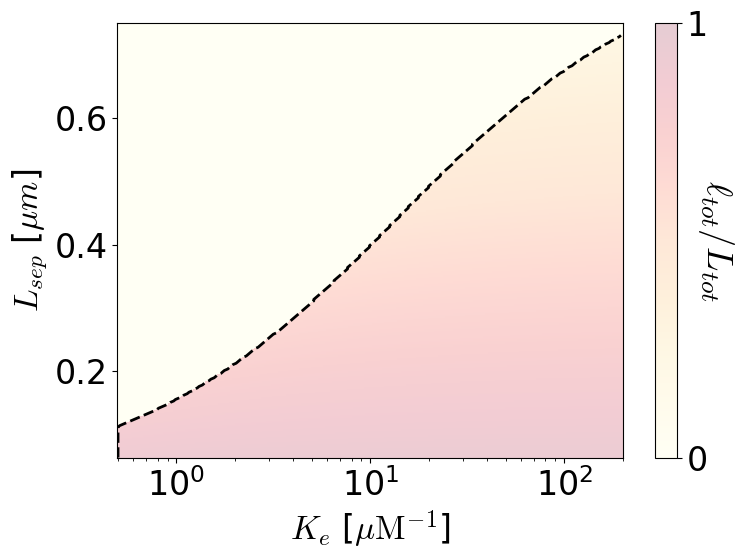

In [ ]:
# Panel C: Theory comparison figure
fig, ax = plt.subplots(figsize=(8, 6))

# Theory parameters
mu = 4.1  # Free energy per volume pN/um^2
alpha = 0.05  # Condensate packing factor um^2
gamma = 0.15  # Surface tension pN/um
kappa = 0.0822  # Filament flexibility pN
Ltot = 1.0  # Total length of the polymer um

# Calculate theoretical predictions
lsep_arr = np.linspace(1, 12, 300)/L_tot_um
ke_arr = np.logspace(np.log10(.5), np.log10(200), 300)
ld_max_prob = np.zeros((lsep_arr.size, ke_arr.size))

for i, lsep in enumerate(lsep_arr):
    for j, ke in enumerate(ke_arr):
        bound = 0.1
        while free_energy_deriv(bound, Ltot, lsep, mu*ke/30., alpha, gamma*ke/30., kappa) > 0:
            bound += 0.5
        if bound > Ltot - (lsep * 1.0000001):
            ld_max_prob[i, j] = 0.0
            continue
        result = root_scalar(
            free_energy_deriv,
            method="brentq",
            bracket=[bound, Ltot - (lsep * 1.0000001)],
            args=(Ltot, lsep, mu*ke, alpha, gamma*ke, kappa),
        )
        ld_max_prob[i, j] = result.root

# Plot heatmap of theoretical predictions
im = ax.pcolormesh(
    ke_arr,
    lsep_arr,
    ld_max_prob / Ltot,
    # shading="auto",
    # cmap="bone_r",
    cmap="YlOrRd",
    # cmap="Greys",
    vmin=0,
    vmax=1,
    alpha=0.2,
)

# Find the boundary between zero and positive values
threshold = 0.01  
boundary_ke = []
boundary_lsep = []
for i, lsep in enumerate(lsep_arr):
    for j, ke in enumerate(ke_arr):
        if ld_max_prob[i, j] / Ltot >= threshold:
            boundary_ke.append(ke)
            boundary_lsep.append(lsep)
            break

# Plot the boundary
ax.plot(boundary_ke, boundary_lsep, color="k", linestyle="--", label="Condensation Boundary")
# ax.legend(loc="upper left", fontsize=12)

# ax.set_xscale("log")
ax.set_xlabel(r"$K_e$ [$\mu {\rm M}^{-1}$]")
ax.set_ylabel(r"$L_{sep}$ [$\mu m$]")
cb = fig.colorbar(im, ax=ax)
cb.set_ticks([0, 1])
cb.set_label(r"$\langle \ell_{tot}/L_{tot} \rangle$", fontsize=26, rotation=-90, labelpad=20)
cb.set_label(r"$\ell_{tot} / L_{tot}$", fontsize=26, rotation=-90, labelpad=20)
ax.set_xscale("log")

fig.tight_layout()



1680


/tmp/ipykernel_3368016/1730690169.py:81: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  _ = axarr[1].scatter(


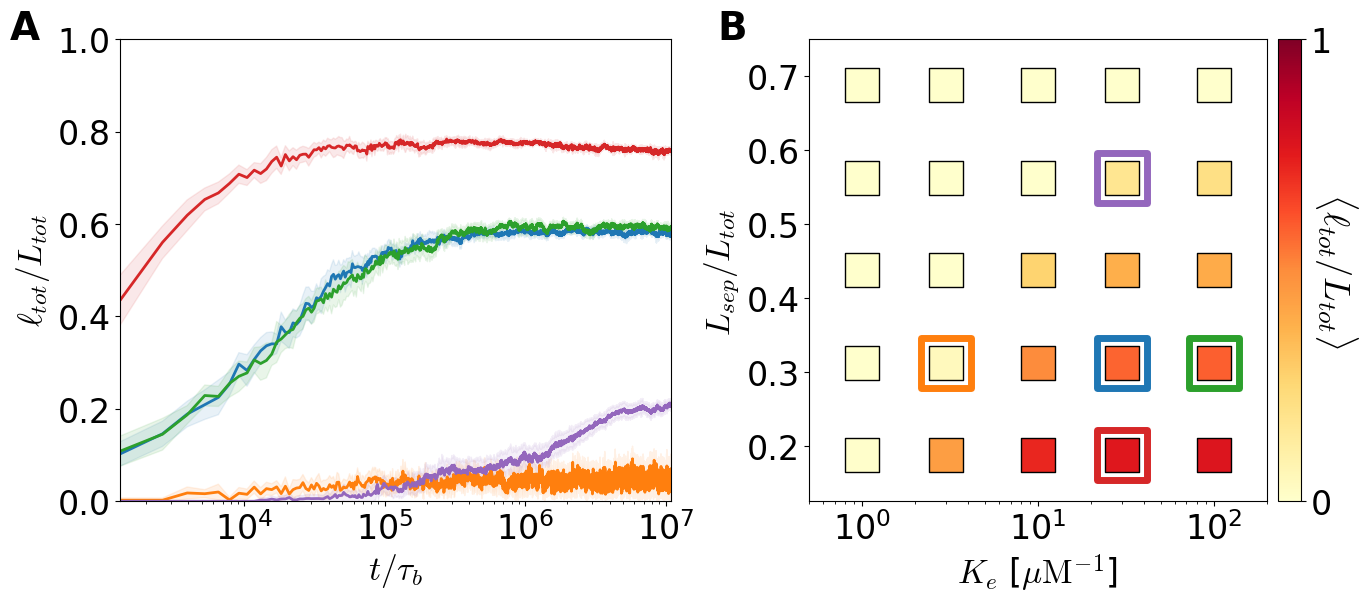

In [ ]:
labels_to_graph_dict = {
    r"$K_e = 3~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke3/",
    # r"$K_e = 10~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke10/",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke30/",
    r"$K_e = 100~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke100",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 3~\mu {\rm m}$": "Pin3.0um_Ke30",
    # r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 7~\mu {\rm m}$": "Pin7.0um_Ke30",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 9~\mu {\rm m}$": "Pin9.0um_Ke30",
}

colors = ["C1", "C0", "C2", "C3", "C4"]

fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(1, 6)

axarr = []
axarr += [fig.add_subplot(gs[0, :3])]
axarr += [fig.add_subplot(gs[0, 3:])]

# Read all data from HDF5 file once
with h5py.File("Figure2/fig2_pin_ke_data_dict.h5", "r") as h5d:
    time_arr = h5d["time"][...]/diff_time
    delta_t = time_arr[1] - time_arr[0]
    
    # Panel A: Time series with confidence intervals
    for (label, key), color in zip(labels_to_graph_dict.items(), colors):
        h5_data = h5d[key]
        tot_cond = h5_data['first_mom'][...] * h5_data['zeroth_mom'][...]
        num_runs = tot_cond.shape[0]
        min_length = min(tot_cond.shape[1], time_arr.size)
        mean = tot_cond[:, :min_length].mean(axis=0)
        std_dev = tot_cond[:, :min_length].std(axis=0)
        
        plot_confidence_int(
            axarr[0],
            time_arr[:min_length],
            mean / L_tot,
            std_dev / L_tot,
            num_runs,
            color=color,
            label=label,
        )
    
    # Panel B: Parameter space heatmap
    data_arr = np.zeros((len(h5d.keys()), 4))
    for i, label in enumerate(h5d.keys()):
        if label != "time":
            h5_data = h5d[label]
            tot_cond = h5_data['first_mom'][...] * h5_data['zeroth_mom'][...]
            data_arr[i, ...] = [
                h5_data.attrs["pin_dist"],
                h5_data.attrs["Ke"],
                tot_cond[-time_arr.size // 5:].mean(),
                tot_cond[-time_arr.size // 5:].std(),
            ]

# Panel A formatting
_ = axarr[0].set_xscale("log")
_ = axarr[0].set_ylabel(r"$\ell_{tot} / L_{tot}$")
# _ = axarr[0].set_xlabel(r"$t$ [$s$]")
_ = axarr[0].set_xlabel(r"$t / \tau_{b}$")
_ = axarr[0].set_xlim(delta_t, time_arr[-1])
_ = axarr[0].set_ylim(0.0, 1.0)

print(time_arr.size // 5)

# Panel B: Color conditions for outlining selected points
conditions = [
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 3),
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 30),
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 100),
    (data_arr[:, 0] == 3.0) & (data_arr[:, 1] == 30),
    (data_arr[:, 0] == 9.0) & (data_arr[:, 1] == 30),
]
color_array = np.select(conditions, colors, default="none")

# Panel B: Outlining boxes
_ = axarr[1].scatter(
    data_arr[:, 1],
    data_arr[:, 0]/ L_tot_um,
    facecolors="none",
    vmin=0,
    vmax=1,
    cmap="YlOrRd",
    s=1300,
    marker="s",
    edgecolors=color_array,
    linewidths=5,
)

# Panel B: Condensed fraction heatmap
_ = axarr[1].set_xscale("log")
_ = axarr[1].scatter(
    data_arr[:, 1],
    data_arr[:, 0]/L_tot_um,
    c=data_arr[:, 2] / L_tot,
    vmin=0,
    vmax=1,
    cmap="YlOrRd",
    s=600,
    marker="s",
    edgecolors="k",
    linewidths=1,
)
cb1 = fig.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=1), cmap="YlOrRd"),
    ax=axarr[1],
    pad=0.02,
)
cb1.set_ticks([0, 1])
cb1.set_label(r"$\langle \ell_{tot}/L_{tot} \rangle$", fontsize=26, rotation=-90, labelpad=20)

_ = axarr[1].set_xlim(0.5, 200)
# _ = axarr[1].set_ylim(2, 12)
_ = axarr[1].set_ylim(2/L_tot_um, 12/L_tot_um)
_ = axarr[1].set_ylabel(r"$L_{sep} / L_{tot}$ ")
_ = axarr[1].set_xlabel(r"$K_e$ [$\mu {\rm M}^{-1}$]")
_ = axarr[1].set_xticks([1, 10, 100])
# _ = axarr[1].set_yticks(np.array([3, 5, 7, 9, 11])/L_tot_um)
# _ = axarr[1].set_yticks(np.array([4, 8, 12])/L_tot_um)
# _ = axarr[1].set_yticks(np.array([.1, .3, .5, .7]))
_ = axarr[1].set_yticks(np.array([.2, .3, .4, .5, .6, .7]))


# Add panel labels
# _ = axarr[0].legend(
#     ncol=5, bbox_to_anchor=(-0.06, 1.05), loc="lower left", fontsize="small"
# )
_ = axarr[0].text(
    -0.2, 1.0, "A", fontsize=28, transform=axarr[0].transAxes, fontweight="bold"
)
_ = axarr[1].text(
    -0.2, 1.0, "B", fontsize=28, transform=axarr[1].transAxes, fontweight="bold"
)

fig.subplots_adjust(hspace=0.3, wspace=1.5)

# fig.savefig("Figure2/fig2_cond_tot.eps", dpi=600, bbox_inches="tight")
# fig.savefig("Figure2/fig2_cond_tot.pdf", dpi=600, bbox_inches="tight")
# fig.savefig(
#     "/mnt/home/alamson/papers/dyn_cond_paper/images/fig2_cond_tot.pdf",
#     dpi=600,
#     bbox_inches="tight",
# )
# fig.savefig(
#     "/mnt/home/alamson/papers/dyn_cond_paper/images/fig2_cond_tot.eps",
#     dpi=600,
#     bbox_inches="tight",
# )


1680


/var/folders/st/fgw_z95d55x71m603j17ld300000gr/T/ipykernel_17473/1806170366.py:90: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  _ = axarr[1].scatter(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


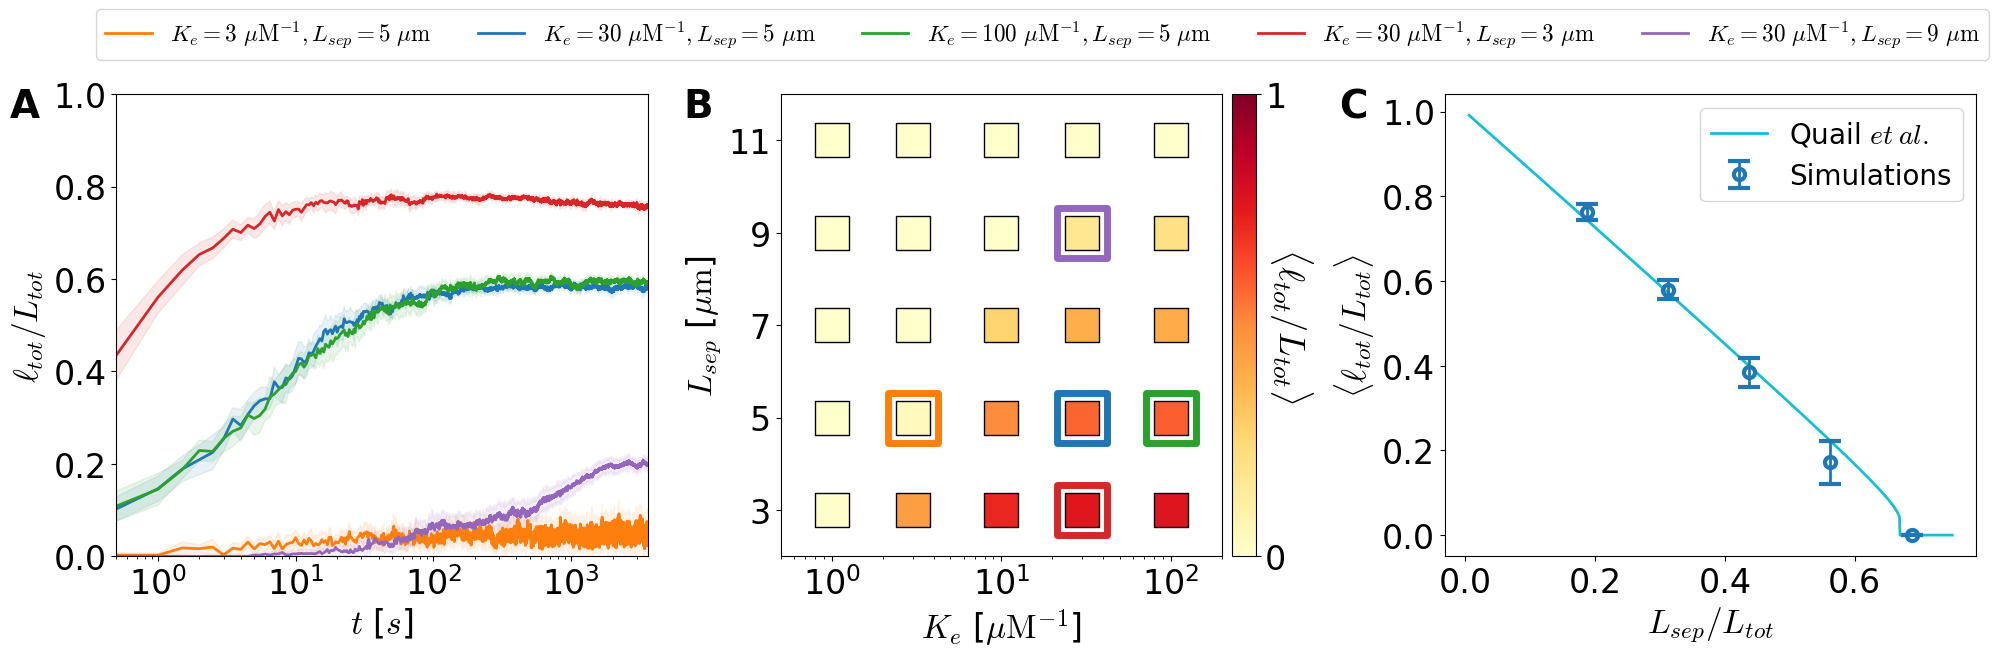

In [ ]:
labels_to_graph_dict = {
    r"$K_e = 3~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke3/",
    # r"$K_e = 10~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke10/",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke30/",
    r"$K_e = 100~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke100",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 3~\mu {\rm m}$": "Pin3.0um_Ke30",
    # r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 7~\mu {\rm m}$": "Pin7.0um_Ke30",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 9~\mu {\rm m}$": "Pin9.0um_Ke30",
}
colors = ["C1", "C0", "C2", "C3", "C4"]

fig = plt.figure(figsize=(24, 6))
gs = gridspec.GridSpec(1, 9)

axarr = []
axarr += [fig.add_subplot(gs[0, :3])]
axarr += [fig.add_subplot(gs[0, 3:6])]
axarr += [fig.add_subplot(gs[0, 6:])]

# Read all data from HDF5 file once
with h5py.File("Figure2/fig2_pin_ke_data_dict.h5", "r") as h5d:
    time_arr = h5d["time"][...]
    
    # Panel A: Time series with confidence intervals
    for (label, key), color in zip(labels_to_graph_dict.items(), colors):
        h5_data = h5d[key]
        tot_cond = h5_data['first_mom'][...] * h5_data['zeroth_mom'][...]
        num_runs = tot_cond.shape[0]
        min_length = min(tot_cond.shape[1], time_arr.size)
        mean = tot_cond[:, :min_length].mean(axis=0)
        std_dev = tot_cond[:, :min_length].std(axis=0)
        
        plot_confidence_int(
            axarr[0],
            time_arr[:min_length],
            mean / 1600,
            std_dev / 1600,
            num_runs,
            color=color,
            label=label,
        )
    
    # Panel B: Parameter space heatmap
    data_arr = np.zeros((len(h5d.keys()), 4))
    for i, label in enumerate(h5d.keys()):
        if label != "time":
            h5_data = h5d[label]
            tot_cond = h5_data['first_mom'][...] * h5_data['zeroth_mom'][...]
            data_arr[i, ...] = [
                h5_data.attrs["pin_dist"],
                h5_data.attrs["Ke"],
                tot_cond[-time_arr.size // 5:].mean(),
                tot_cond[-time_arr.size // 5:].std(),
            ]
    
    # Panel C: Extract Ke=30 data for theory comparison
    pin_dist_arr = []
    beads_num_arr = []
    beads_std_arr = []
    for label in h5d.keys():
        if label != "time":
            h5_data = h5d[label]
            Ke, pin_dist = h5_data.attrs["Ke"], h5_data.attrs["pin_dist"]
            if Ke == 30:
                pin_dist_arr.append(pin_dist)
                tot_cond = h5_data['first_mom'][...] * h5_data['zeroth_mom'][...]
                beads_num_arr.append(tot_cond[-time_arr.size // 5:].mean())
                beads_std_arr.append(tot_cond[-time_arr.size // 5:].std())

# Panel A formatting
_ = axarr[0].set_xscale("log")
_ = axarr[0].set_ylabel(r"$\ell_{tot} / L_{tot}$")
_ = axarr[0].set_xlabel(r"$t$ [$s$]")
_ = axarr[0].set_xlim(5e-1, 3600)
_ = axarr[0].set_ylim(0.0, 1.0)

print(time_arr.size // 5)

# Panel B: Color conditions for outlining selected points
conditions = [
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 3),
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 30),
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 100),
    (data_arr[:, 0] == 3.0) & (data_arr[:, 1] == 30),
    (data_arr[:, 0] == 9.0) & (data_arr[:, 1] == 30),
]
color_array = np.select(conditions, colors, default="none")

# Panel B: Outlining boxes
_ = axarr[1].scatter(
    data_arr[:, 1],
    data_arr[:, 0],
    facecolors="none",
    vmin=0,
    vmax=1,
    cmap="YlOrRd",
    s=1300,
    marker="s",
    edgecolors=color_array,
    linewidths=5,
)

# Panel B: Condensed fraction heatmap
_ = axarr[1].set_xscale("log")
_ = axarr[1].scatter(
    data_arr[:, 1],
    data_arr[:, 0],
    c=data_arr[:, 2] / 1600,
    vmin=0,
    vmax=1,
    cmap="YlOrRd",
    s=600,
    marker="s",
    edgecolors="k",
    linewidths=1,
)
cb1 = fig.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=1), cmap="YlOrRd"),
    ax=axarr[1],
    pad=0.02,
)
cb1.set_ticks([0, 1])
cb1.set_label(r"$\langle \ell_{tot}/L_{tot} \rangle$", fontsize=26, rotation=-90, labelpad=20)

_ = axarr[1].set_xlim(0.5, 200)
_ = axarr[1].set_ylim(2, 12)
_ = axarr[1].set_ylabel(r"$L_{sep}$ [$\mu {\rm m}$]")
_ = axarr[1].set_xlabel(r"$K_e$ [$\mu {\rm M}^{-1}$]")
_ = axarr[1].set_xticks([1, 10, 100])
_ = axarr[1].set_yticks([3, 5, 7, 9, 11])

# Panel C: Comparison with theory from equilibrium model
mu = 4.1  # Free energy per volume pN/um^2
alpha = 0.05  # Condensate packing factor um^2
gamma = 0.15  # Surface tension pN/um
kappa = 0.0822  # Filament flexibility pN
Ltot = 16.0  # Total length of the polymer um

# Calculate theoretical predictions
lsep_arr = np.linspace(0.1, 12, 1000)
ld_max_prob = np.zeros(lsep_arr.size)

for i, lsep in enumerate(lsep_arr):
    bound = 0.1
    while free_energy_deriv(bound, Ltot, lsep, mu, alpha, gamma, kappa) > 0:
        bound += 0.5
    if bound > Ltot - (lsep * 1.0000001):
        ld_max_prob[i] = 0.0
        continue
    result = root_scalar(
        free_energy_deriv,
        method="brentq",
        bracket=[bound, Ltot - (lsep * 1.0000001)],
        args=(Ltot, lsep, mu, alpha, gamma, kappa),
    )
    ld_max_prob[i] = result.root

_ = axarr[2].plot(
    lsep_arr / Ltot,
    ld_max_prob / Ltot,
    label=r"Quail $\mathit{et\:al.}$",
    color="C9",
)
_ = axarr[2].errorbar(
    np.array(pin_dist_arr) / 16.0,
    np.array(beads_num_arr) / 1600.0,
    yerr=np.array(beads_std_arr) / 1600.0,
    fmt="o",
    markeredgewidth=3,
    markeredgecolor="C0",
    markersize=8,
    markerfacecolor="none",
    capsize=8,
    label="Simulations",
)
_ = axarr[2].set_xlabel(r"$L_{sep}/L_{tot}$")
_ = axarr[2].set_ylabel(r"$\langle \ell_{tot}/L_{tot} \rangle$")
_ = axarr[2].legend()

# Add panel labels
_ = axarr[0].legend(
    ncol=5, bbox_to_anchor=(-0.06, 1.05), loc="lower left", fontsize="small"
)
_ = axarr[0].text(
    -0.2, 0.95, "A", fontsize=28, transform=axarr[0].transAxes, fontweight="bold"
)
_ = axarr[1].text(
    -0.22, 0.95, "B", fontsize=28, transform=axarr[1].transAxes, fontweight="bold"
)
_ = axarr[2].text(
    -0.2, 0.95, "C", fontsize=28, transform=axarr[2].transAxes, fontweight="bold"
)

fig.subplots_adjust(hspace=0.3, wspace=1.5)

fig.savefig("Figure2/fig2_cond_tot.eps", dpi=600, bbox_inches="tight")
fig.savefig("Figure2/fig2_cond_tot.pdf", dpi=600, bbox_inches="tight")


3601
3601
3601
3601
3601
720


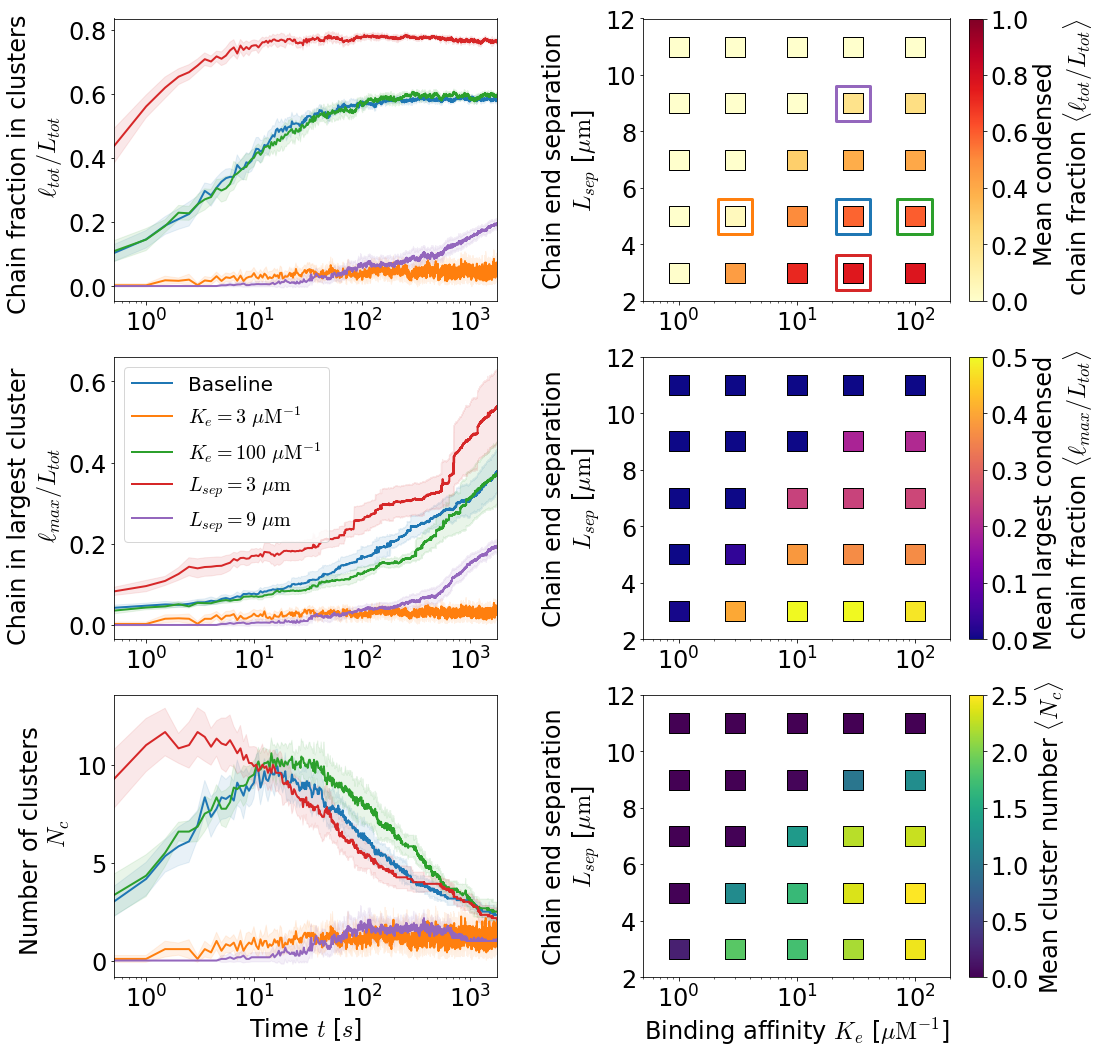

In [ ]:
labels_to_graph_dict = {
    "Baseline": "Pin5.0um_Ke30/",
    r"$K_e = 3~\mu {\rm M}^{-1}$": "Pin5.0um_Ke3/",
    r"$K_e = 100~\mu {\rm M}^{-1}$": "Pin5.0um_Ke100",
    r"$L_{sep} = 3~\mu {\rm m}$": "Pin3.0um_Ke30",
    r"$L_{sep} = 9~\mu {\rm m}$": "Pin9.0um_Ke30",
}

fig = plt.figure(figsize=(16, 15))
gs = gridspec.GridSpec(3, 6)

axarr = []
axarr += [fig.add_subplot(gs[0, :3])]
axarr += [fig.add_subplot(gs[1, :3], sharex=axarr[0])]
axarr += [fig.add_subplot(gs[2, :3], sharex=axarr[0])]
axarr += [fig.add_subplot(gs[0, 3:])]
axarr += [fig.add_subplot(gs[1, 3:], sharex=axarr[3], sharey=axarr[3])]
axarr += [fig.add_subplot(gs[2, 3:], sharex=axarr[3], sharey=axarr[3])]

tableau10_cycler = iter(cycler(color=plt.cm.tab10.colors))
with h5py.File("Figure2/fig2_pin_ke_data_dict.h5", "r") as h5d:
    time_arr = h5d["time"][...]
    for (label, key), color in zip(labels_to_graph_dict.items(), plt.cm.tab10.colors):
        h5_data = h5d[key]

        num_runs = h5_data.attrs["num_runs"]
        mean = h5_data[:, 0]
        min_length = min(mean.size, time_arr.size)
        print(min_length)
        mean = h5_data[:min_length, 0]
        std_dev = h5_data[:min_length, 1]
        # num_runs = h5_data.attrs['num_runs']
        plot_confidence_int(
            axarr[0],
            time_arr[:min_length],
            mean / 1600,
            std_dev / 1600,
            12,
            color=color,
            label=label,
        )

        mean = h5_data[:min_length, 4]
        std_dev = h5_data[:min_length, 5]
        num_runs = h5_data.attrs["num_runs"]
        plot_confidence_int(
            axarr[1],
            time_arr[:min_length],
            mean / 1600,
            std_dev / 1600,
            num_runs,
            color=color,
            label=label,
        )

        mean = h5_data[:min_length, 2]
        std_dev = h5_data[:min_length, 3]
        num_runs = h5_data.attrs["num_runs"]
        plot_confidence_int(
            axarr[2],
            time_arr[:min_length],
            mean,
            std_dev,
            num_runs,
            color=color,
            label=label,
        )

    _ = axarr[0].set_ylabel("Chain fraction in clusters \n $\ell_{tot} / L_{tot}$")
    _ = axarr[0].set_xscale("log")

    _ = axarr[1].set_ylabel("Chain in largest cluster  \n $\ell_{max} / L_{tot}$")
    _ = axarr[1].legend(loc="upper left", bbox_to_anchor=(0, 1.0))

    _ = axarr[2].set_ylabel("Number of clusters \n $N_c$")
    _ = axarr[2].set_xlabel("Time $t$ [$s$]")
_ = axarr[0].set_xlim(5e-1, 1800)

with h5py.File("Figure2/fig2_pin_ke_data_dict.h5", "r") as h5d:
    data_arr = np.zeros((len(h5d.keys()), 8))
    labels = []
    time_arr = h5d["time"][...]
    for i, label in enumerate(h5d.keys()):
        if label != "time":
            h5_data = h5d[label]
            data_arr[i, ...] = [
                h5_data.attrs["pin_dist"],
                h5_data.attrs["Ke"],
                h5_data[-time_arr.size // 5 :, 0].mean(),
                h5_data[-time_arr.size // 5 :, 1].mean(),
                h5_data[-time_arr.size // 5 :, 2].mean(),
                h5_data[-time_arr.size // 5 :, 3].mean(),
                h5_data[-time_arr.size // 5 :, 4].mean(),
                h5_data[-time_arr.size // 5 :, 5].mean(),
            ]
print(time_arr.size // 5)

# Define the color conditions
conditions = [
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 30),
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 3),
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 100),
    (data_arr[:, 0] == 3.0) & (data_arr[:, 1] == 30),
    (data_arr[:, 0] == 9.0) & (data_arr[:, 1] == 30),
]

# Define the color for each condition
colors = ["C0", "C1", "C2", "C3", "C4"]

# Use np.select to assign colors to the conditions
color_array = np.select(conditions, colors, default="none")

_ = axarr[3].scatter(
    data_arr[:, 1],
    data_arr[:, 0],
    facecolors="none",
    # c=data_arr[:, 2] / 1600,
    vmin=0,
    vmax=1,
    cmap="YlOrRd",
    s=1200,
    marker="s",
    edgecolors=color_array,
    linewidths=3,
)
## Condensed fraction graph
_ = axarr[3].set_xscale("log")
_ = axarr[3].scatter(
    data_arr[:, 1],
    data_arr[:, 0],
    c=data_arr[:, 2] / 1600,
    vmin=0,
    vmax=1,
    cmap="YlOrRd",
    s=400,
    marker="s",
    edgecolors="k",
    linewidths=1,
)
cb1 = fig.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=1), cmap="YlOrRd"),
    ax=axarr[3],
    label="Mean condensed \n chain fraction" + r" $\langle \ell_{tot}/L_{tot} \rangle$",
)

## Max cluster fraction
msc = axarr[4].scatter(
    data_arr[:, 1],
    data_arr[:, 0],
    c=data_arr[:, 6] / 1600,
    cmap="plasma",
    vmin=0,
    vmax=0.5,
    s=400,
    marker="s",
    edgecolors="k",
    linewidths=1,
)

cb1 = fig.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=0.5), cmap="plasma"),
    ax=axarr[4],
    label="Mean largest condensed \n chain fraction"
    + r" $\langle \ell_{max}/L_{tot} \rangle$",
)

## Number of cluster graph

sc = axarr[5].scatter(
    data_arr[:, 1],
    data_arr[:, 0],
    c=data_arr[:, 4],
    cmap="viridis",
    s=400,
    marker="s",
    edgecolors="k",
    linewidths=1,
)

# Create a colorbar
cb2 = fig.colorbar(
    mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0, vmax=int(np.max(data_arr[:, 4])) + 0.5),
        cmap="viridis",
    ),
    ax=axarr[5],
    label=r"Mean cluster number $\langle N_c \rangle$",
)

_ = axarr[3].set_xlim(0.5, 200)
_ = axarr[3].set_ylim(2, 12)

for ax in axarr[3:]:
    # _ = ax.set_xlabel(r"Binding affinity [$\mu {\rm M}^{-1}$]")
    _ = ax.set_ylabel(r"Chain end separation" + "\n" + r"$L_{sep}$ [$\mu {\rm m}$]")
_ = axarr[5].set_xlabel(r"Binding affinity $K_e$ [$\mu {\rm M}^{-1}$]")

fig.tight_layout()
fig.savefig("Figure2/fig2_combined.png", dpi=300, bbox_inches="tight")


7201
7201
7201
7201
7201
1440


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.


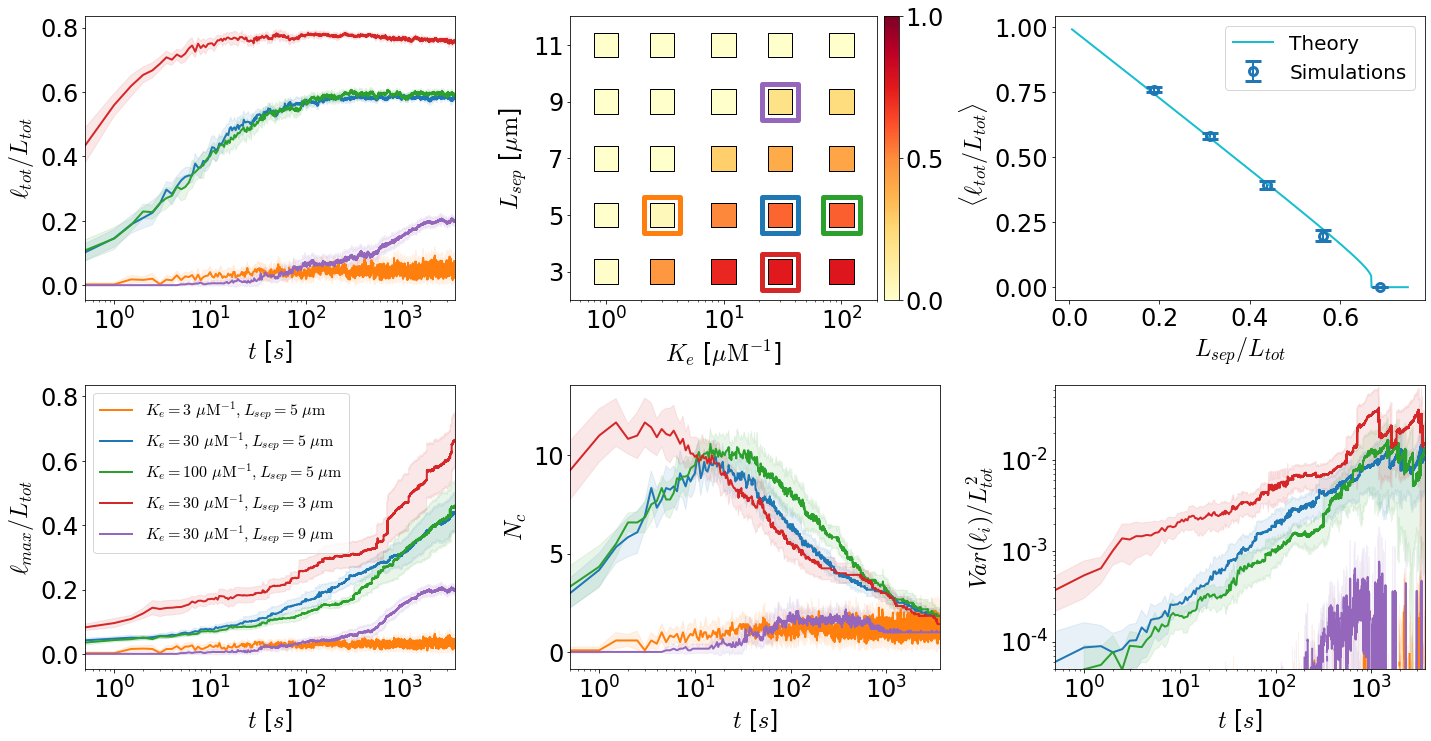

In [ ]:
labels_to_graph_dict = {
    r"$K_e = 3~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke3/",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke30/",
    r"$K_e = 100~\mu {\rm M}^{-1}, L_{sep} = 5~\mu {\rm m}$": "Pin5.0um_Ke100",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 3~\mu {\rm m}$": "Pin3.0um_Ke30",
    r"$K_e = 30~\mu {\rm M}^{-1}, L_{sep} = 9~\mu {\rm m}$": "Pin9.0um_Ke30",
}
colors = ["C1", "C0", "C2", "C3", "C4"]

fig = plt.figure(figsize=(24, 12))
gs = gridspec.GridSpec(2, 9)

axarr = []
axarr += [fig.add_subplot(gs[0, :3])]
axarr += [fig.add_subplot(gs[0, 3:6])]
axarr += [fig.add_subplot(gs[0, 6:])]
axarr += [fig.add_subplot(gs[1, :3], sharex=axarr[0], sharey=axarr[0])]
axarr += [fig.add_subplot(gs[1, 3:6], sharex=axarr[0])]
axarr += [fig.add_subplot(gs[1, 6:], sharex=axarr[0])]
# axarr +=[fig.add_subplot(gs[1,6:], sharex=axarr[0])]

with h5py.File("Figure2/fig2_pin_ke_data_dict.h5", "r") as h5d:
    time_arr = h5d["time"][...]
    for (label, key), color in zip(labels_to_graph_dict.items(), colors):
        h5_data = h5d[key]

        num_runs = h5_data.attrs["num_runs"]
        mean = h5_data[:, 0]
        min_length = min(mean.size, time_arr.size)
        print(min_length)
        mean = h5_data[:min_length, 0]
        std_dev = h5_data[:min_length, 1]

        # Plot total condensed fraction
        plot_confidence_int(
            axarr[0],
            time_arr[:min_length],
            mean / 1600,
            std_dev / 1600,
            12,
            color=color,
            label=label,
        )

        # Plot chain in largest cluster
        mean = h5_data[:min_length, 4]
        std_dev = h5_data[:min_length, 5]
        num_runs = h5_data.attrs["num_runs"]
        plot_confidence_int(
            axarr[3],
            time_arr[:min_length],
            mean / 1600,
            std_dev / 1600,
            num_runs,
            color=color,
            label=label,
        )

        # Plot number of clusters
        mean = h5_data[:min_length, 2]
        std_dev = h5_data[:min_length, 3]
        num_runs = h5_data.attrs["num_runs"]
        plot_confidence_int(
            axarr[4],
            time_arr[:min_length],
            mean,
            std_dev,
            num_runs,
            color=color,
            label=label,
        )

        # Plot variance of cluster size
        mean = h5_data[:min_length, 6]
        std_dev = h5_data[:min_length, 7]
        num_runs = h5_data.attrs["num_runs"]
        plot_confidence_int(
            axarr[5],
            time_arr[:min_length],
            mean / (1600**2),
            std_dev / (1600**2),
            num_runs,
            color=color,
            label=label,
        )

    _ = axarr[0].set_xscale("log")
    _ = axarr[0].set_ylabel(r"$\ell_{tot} / L_{tot}$")

    _ = axarr[3].set_ylabel(r"$\ell_{max} / L_{tot}$")
    _ = axarr[3].set_ylabel(r"$\ell_{max} / L_{tot}$")

    _ = axarr[5].set_ylabel(r"$Var(\ell_i)/ L_{tot}^2$")
    _ = axarr[5].set_ylim(0.00005)
    _ = axarr[5].set_yscale("log")

    _ = axarr[4].set_ylabel("$N_c$")
    _ = axarr[0].set_xlabel("$t$ [$s$]")
    _ = axarr[3].set_xlabel("$t$ [$s$]")
    _ = axarr[4].set_xlabel("$t$ [$s$]")
    _ = axarr[5].set_xlabel("$t$ [$s$]")
_ = axarr[0].set_xlim(5e-1, 3600)

with h5py.File("Figure2/fig2_pin_ke_data_dict.h5", "r") as h5d:
    data_arr = np.zeros((len(h5d.keys()), 8))
    labels = []
    time_arr = h5d["time"][...]
    for i, label in enumerate(h5d.keys()):
        if label != "time":
            h5_data = h5d[label]
            data_arr[i, ...] = [
                h5_data.attrs["pin_dist"],
                h5_data.attrs["Ke"],
                h5_data[-time_arr.size // 5 :, 0].mean(),
                h5_data[-time_arr.size // 5 :, 1].mean(),
                h5_data[-time_arr.size // 5 :, 2].mean(),
                h5_data[-time_arr.size // 5 :, 3].mean(),
                h5_data[-time_arr.size // 5 :, 4].mean(),
                h5_data[-time_arr.size // 5 :, 5].mean(),
            ]
print(time_arr.size // 5)

## Draw boxes around the selected points

# Define the color conditions
conditions = [
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 3),
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 30),
    (data_arr[:, 0] == 5.0) & (data_arr[:, 1] == 100),
    (data_arr[:, 0] == 3.0) & (data_arr[:, 1] == 30),
    (data_arr[:, 0] == 9.0) & (data_arr[:, 1] == 30),
]

# Define the color for each condition
colors = ["C1", "C0", "C2", "C3", "C4"]

# Use np.select to assign colors to the conditions
color_array = np.select(conditions, colors, default="none")

# Graph outlining boxes
_ = axarr[1].scatter(
    data_arr[:, 1],
    data_arr[:, 0],
    facecolors="none",
    # c=data_arr[:, 2] / 1600,
    vmin=0,
    vmax=1,
    cmap="YlOrRd",
    s=1300,
    marker="s",
    edgecolors=color_array,
    linewidths=5,
)

## Condensed fraction graph
_ = axarr[1].set_xscale("log")
_ = axarr[1].scatter(
    data_arr[:, 1],
    data_arr[:, 0],
    c=data_arr[:, 2] / 1600,
    vmin=0,
    vmax=1,
    cmap="YlOrRd",
    s=600,
    marker="s",
    edgecolors="k",
    linewidths=1,
)
cb1 = fig.colorbar(
    mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=1), cmap="YlOrRd"),
    ax=axarr[1],
    pad=0.02,
    # label=r" $\langle \ell_{tot}/L_{tot} \rangle$",
    # label="Mean condensed \n chain fraction" + r" $\langle \ell_{tot}/L_{tot} \rangle$",
)
cb1.set_ticks([0, 0.5, 1])


_ = axarr[1].set_xlim(0.5, 200)
_ = axarr[1].set_ylim(2, 12)

_ = axarr[1].set_ylabel(r"$L_{sep}$ [$\mu {\rm m}$]")
_ = axarr[1].set_xlabel(r"$K_e$ [$\mu {\rm M}^{-1}$]")

_ = axarr[1].set_xticks([1, 10, 100])
_ = axarr[1].set_yticks([3, 5, 7, 9, 11])


## Comparison with theory from equilibrium model

mu = 4.1  # Free energy per volume pN/um^2
alpha = 0.05  # Condensate packing factor um^2
gamma = 0.15  # Surface tension pN/um
kappa = 0.0822  # Filament flexibility pN
Ltot = 16.0  # Total length of the polymer um

beta = 1.0 / 0.0041
# fig, axarr = plt.subplots(1, 1, figsize=(5, 5))


# Get theoretical results
lsep_arr = np.linspace(0.1, 12, 1000)

ld_max_prob = np.zeros(lsep_arr.size)
for i, lsep in enumerate(lsep_arr):
    bound = 0.1
    while free_energy_deriv(bound, Ltot, lsep, mu, alpha, gamma, kappa) > 0:
        bound += 0.5
    if bound > Ltot - (lsep * 1.0000001):
        ld_max_prob[i] = 0.0
        continue
    # free_energy_deriv(bound, Ltot, lsep, mu, alpha, gamma, kappa)
    # free_energy_deriv(Ltot-(lsep*1.0000001), Ltot, lsep, mu, alpha, gamma, kappa)
    result = root_scalar(
        free_energy_deriv,
        method="brentq",
        bracket=[bound, Ltot - (lsep * 1.0000001)],
        args=(Ltot, lsep, mu, alpha, gamma, kappa),
    )
    ld_max_prob[i] = result.root
_ = axarr[2].plot(lsep_arr / Ltot, ld_max_prob / Ltot, label="Theory", color="C9")
_ = axarr[2].set_xlabel(r"$L_{sep}/L_{tot}$")
_ = (axarr[2].set_ylabel(r" $\langle \ell_{tot}/L_{tot} \rangle$"),)

with h5py.File("Figure2/fig2_pin_ke_data_dict.h5", "r") as h5d:
    time_arr = h5d["time"][...]

    pin_dist_arr = []
    beads_num_arr = []
    beads_std_arr = []
    for i, label in enumerate(h5d.keys()):
        if label != "time":
            h5_data = h5d[label]
            Ke, pin_dist = h5_data.attrs["Ke"], h5_data.attrs["pin_dist"]
            if Ke == 30:
                pin_dist_arr += [pin_dist]
                beads_num_arr += [h5_data[time_arr.size // 2 :, 0].mean()]
                beads_std_arr += [h5_data[time_arr.size // 2 :, 1].mean()]

    _ = axarr[2].errorbar(
        np.array(pin_dist_arr) / 16.0,
        np.array(beads_num_arr) / 1600.0,
        yerr=np.array(beads_std_arr) / 1600.0,
        fmt="o",
        markeredgewidth=3,
        markeredgecolor="C0",
        markersize=8,
        markerfacecolor="none",
        capsize=8,
        label="Simulations",
    )

_ = axarr[2].legend()
_ = axarr[3].legend(fontsize=16)
# _ = axarr[4].legend(loc='center left', bbox_to_anchor=(1.05, .5))
# fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.5, hspace=0.5)
fig.subplots_adjust(hspace=0.3, wspace=2.5)
# fig.tight_layout()

fig.savefig("Figure2/fig2_combined.png", dpi=300, bbox_inches="tight")
